#### 📉 Indian Stock Market Analysis (2020–2025)

## Problem Statement
Analyzing price trends, sector behavior, and market reactions
to major real-world events across key NIFTY 50 stocks from January 2020 to March 2026.

## Stocks Covered
- **IT:** TCS, Infosys, Wipro
- **Banking:** HDFC Bank, ICICI Bank, SBI
- **Energy:** Reliance, ONGC
- **FMCG:** Hindustan Unilever, Nestle India

## Key Questions
1. How did stock prices change over time?
2. Which stocks go up and down the most?
3. Which stocks are the riskiest?
4. Do some stocks always move together?

In [1]:
#Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf

In [2]:
#Loading the data

all_tickers = [
    'TCS.NS', 'INFY.NS', 'WIPRO.NS',           # IT companies
    'HDFCBANK.NS', 'ICICIBANK.NS', 'SBIN.NS',   # Banks
    'RELIANCE.NS', 'ONGC.NS',                   # Energy companies
    'HINDUNILVR.NS', 'NESTLEIND.NS'             # FMCG companies
]

df = yf.download(all_tickers, start='2020-01-01', end='2025-12-31')['Close']
df.head()

[*********************100%***********************]  10 of 10 completed


Ticker,HDFCBANK.NS,HINDUNILVR.NS,ICICIBANK.NS,INFY.NS,NESTLEIND.NS,ONGC.NS,RELIANCE.NS,SBIN.NS,TCS.NS,WIPRO.NS
Date,,,,,,,,,,
2020-01-01,605.529297,1749.931274,519.137939,633.150940,690.580811,85.371384,675.324219,308.602631,1866.113770,113.709175
2020-01-02,609.389099,1751.286621,522.861633,631.303772,688.258606,85.773308,686.821167,313.077728,1857.547485,113.984619
2020-01-03,600.698853,1741.708130,521.169067,641.013428,681.915283,86.041222,687.648804,307.910522,1894.566406,115.269981
2020-01-06,587.698792,1730.864868,508.450470,634.869751,673.646973,84.567566,671.700684,294.346619,1894.395142,115.751999
2020-01-07,597.004761,1735.608643,505.742401,625.460632,667.764038,84.232666,682.034607,293.792969,1899.043701,117.152130


In [3]:
#Basic check on the data 

print("Shape of the data: ",df.shape)

print("\nMissing values: ")
print(df.isna().sum())

print('\nData Types:')
print(df.dtypes)

print("\nBasic Statistics: ")
print(df.describe().round(3))

Shape of the data:  (1486, 10)

Missing values: 
Ticker
HDFCBANK.NS      0
HINDUNILVR.NS    0
ICICIBANK.NS     0
INFY.NS          0
NESTLEIND.NS     0
ONGC.NS          0
RELIANCE.NS      0
SBIN.NS          0
TCS.NS           0
WIPRO.NS         0
dtype: int64

Data Types:
Ticker
HDFCBANK.NS      float64
HINDUNILVR.NS    float64
ICICIBANK.NS     float64
INFY.NS          float64
NESTLEIND.NS     float64
ONGC.NS          float64
RELIANCE.NS      float64
SBIN.NS          float64
TCS.NS           float64
WIPRO.NS         float64
dtype: object

Basic Statistics: 
Ticker  HDFCBANK.NS  HINDUNILVR.NS  ICICIBANK.NS   INFY.NS  NESTLEIND.NS  \
count      1486.000       1486.000      1486.000  1486.000      1486.000   
mean        743.421       2282.386       873.545  1344.052       995.132   
std         134.226        225.547       327.581   324.144       176.909   
min         363.573       1661.149       274.681   452.361       604.865   
25%         678.582       2134.764       628.926  1206.89

In [4]:
name_map = {
    'HDFCBANK.NS'   : 'HDFC Bank',
    'HINDUNILVR.NS' : 'HUL',
    'ICICIBANK.NS'  : 'ICICI Bank',
    'INFY.NS'       : 'Infosys',
    'NESTLEIND.NS'  : 'Nestle',
    'ONGC.NS'       : 'ONGC',
    'RELIANCE.NS'   : 'Reliance',
    'SBIN.NS'       : 'SBI',
    'TCS.NS'        : 'TCS',
    'WIPRO.NS'      : 'Wipro'
}

df.columns = [name_map[col] for col in df.columns]

sectors = {
    'IT'      : ['TCS', 'Infosys', 'Wipro'],
    'Banking' : ['HDFC Bank', 'ICICI Bank', 'SBI'],
    'Energy'  : ['Reliance', 'ONGC'],
    'FMCG'    : ['HUL', 'Nestle']
}

sector_map = {
    'TCS'        : 'IT',
    'Infosys'    : 'IT',
    'Wipro'      : 'IT',
    'HDFC Bank'  : 'Banking',
    'ICICI Bank' : 'Banking',
    'SBI'        : 'Banking',
    'Reliance'   : 'Energy',
    'ONGC'       : 'Energy',
    'HUL'        : 'FMCG',
    'Nestle'     : 'FMCG'
}

sector_colors = {
    'TCS'        : 'steelblue',
    'Infosys'    : 'steelblue',
    'Wipro'      : 'steelblue',
    'HDFC Bank'  : 'green',
    'ICICI Bank' : 'green',
    'SBI'        : 'green',
    'Reliance'   : 'orange',
    'ONGC'       : 'orange',
    'HUL'        : 'purple',
    'Nestle'     : 'purple'
}
df.head()

,HDFC Bank,HUL,ICICI Bank,Infosys,Nestle,ONGC,Reliance,SBI,TCS,Wipro
Date,,,,,,,,,,
2020-01-01,605.529297,1749.931274,519.137939,633.150940,690.580811,85.371384,675.324219,308.602631,1866.113770,113.709175
2020-01-02,609.389099,1751.286621,522.861633,631.303772,688.258606,85.773308,686.821167,313.077728,1857.547485,113.984619
2020-01-03,600.698853,1741.708130,521.169067,641.013428,681.915283,86.041222,687.648804,307.910522,1894.566406,115.269981
2020-01-06,587.698792,1730.864868,508.450470,634.869751,673.646973,84.567566,671.700684,294.346619,1894.395142,115.751999
2020-01-07,597.004761,1735.608643,505.742401,625.460632,667.764038,84.232666,682.034607,293.792969,1899.043701,117.152130


In [5]:
returns = df.pct_change().dropna()

print('Returns data shape:', returns.shape)
print('\nSample — first 5 rows of daily returns:')
print(returns.head().round(4))

Returns data shape: (1485, 10)

Sample — first 5 rows of daily returns:
            HDFC Bank     HUL  ICICI Bank  Infosys  Nestle    ONGC  Reliance  \
Date                                                                           
2020-01-02     0.0064  0.0008      0.0072  -0.0029 -0.0034  0.0047    0.0170   
2020-01-03    -0.0143 -0.0055     -0.0032   0.0154 -0.0092  0.0031    0.0012   
2020-01-06    -0.0216 -0.0062     -0.0244  -0.0096 -0.0121 -0.0171   -0.0232   
2020-01-07     0.0158  0.0027     -0.0053  -0.0148 -0.0087 -0.0040    0.0154   
2020-01-08    -0.0026  0.0045      0.0058  -0.0133  0.0070 -0.0183   -0.0075   

               SBI     TCS   Wipro  
Date                                
2020-01-02  0.0145 -0.0046  0.0024  
2020-01-03 -0.0165  0.0199  0.0113  
2020-01-06 -0.0441 -0.0001  0.0042  
2020-01-07 -0.0019  0.0025  0.0121  
2020-01-08  0.0044  0.0224 -0.0016  


---
## 📊 Analysis Section

### Plot 1 — Stock Price Trends
**What are we looking at?**
The closing price of each stock from 2020 to 2025.

**What do the dotted lines mean?**
Each dotted line marks a major real-world event that affected the stock market.
This helps us see how news and world events impact stock prices directly.

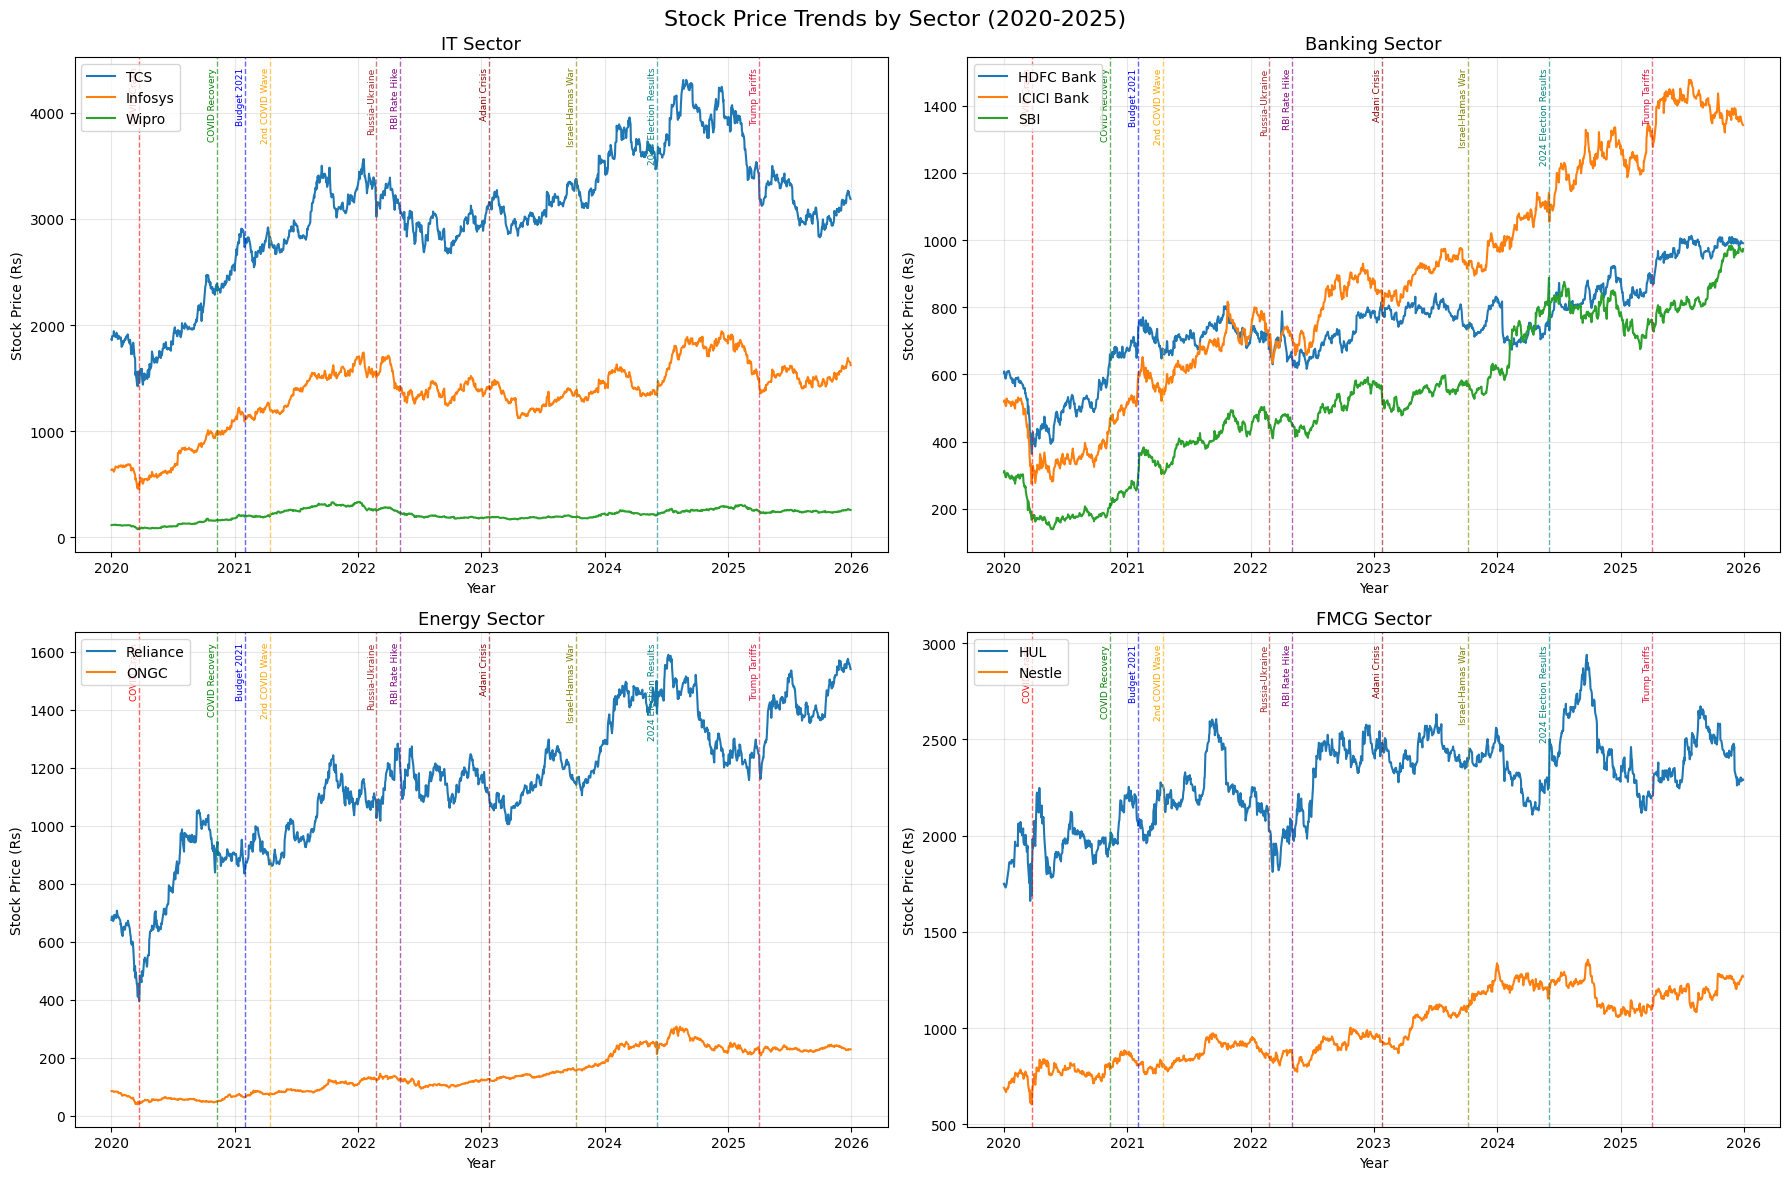

In [6]:
events = {
    'COVID Crash'      : ('2020-03-23', 'red'),
    'COVID Recovery'   : ('2020-11-09', 'green'),
    'Budget 2021'      : ('2021-02-01', 'blue'),
    '2nd COVID Wave'   : ('2021-04-15', 'orange'),
    'Russia-Ukraine'   : ('2022-02-24', 'brown'),
    'RBI Rate Hike'    : ('2022-05-04', 'purple'),
    'Adani Crisis'     : ('2023-01-24', 'darkred'),
    'Israel-Hamas War'     : ('2023-10-07', 'olive'),
    '2024 Election Results' : ('2024-06-04', 'teal'),
    'Trump Tariffs'    : ('2025-04-03', 'crimson'),
}

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('Stock Price Trends by Sector (2020-2025)',fontsize=16)

ax1 = axes[0][0]  # top left     = IT
ax2 = axes[0][1]  # top right    = Banking
ax3 = axes[1][0]  # bottom left  = Energy
ax4 = axes[1][1]  # bottom right = FMCG

ax_list     = [ax1, ax2, ax3, ax4]
sector_list = ['IT', 'Banking', 'Energy', 'FMCG']

for i in range(4):
    ax     = ax_list[i]
    sector = sector_list[i]
    stocks = sectors[sector]

    for stock in stocks:
        ax.plot(df.index, df[stock], label=stock, linewidth=1.5)

    for event in events:
        date  = events[event][0]
        color = events[event][1]
        ax.axvline(pd.Timestamp(date), color=color,
                   linestyle='--', alpha=0.6, linewidth=1)
        ax.text(pd.Timestamp(date), ax.get_ylim()[1] * 0.98,
                event, rotation=90, fontsize=6.5,
                color=color, va='top', ha='right')

    ax.set_title(sector + ' Sector', fontsize=13)
    ax.set_xlabel('Year')
    ax.set_ylabel('Stock Price (Rs)')
    ax.legend(loc='upper left')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**What we can see from this plot:**
- All stocks dropped sharply in March 2020 when COVID lockdown was announced
- Markets recovered strongly after the vaccine news in November 2020
- SBI and ONGC grew the most over 6 years
- HUL and TCS grew the least — stable but slow
- Election Results in June 2024 caused a sudden dip visible in all sectors

---
### Plot 2 — How Much Do Stocks Move Each Day?
Daily Return: Each day a stock goes up or down by some percentage.

A stock that moves a lot each day (wide histogram) = **risky**.

A stock that barely moves (narrow histogram) = **safe/stable**.

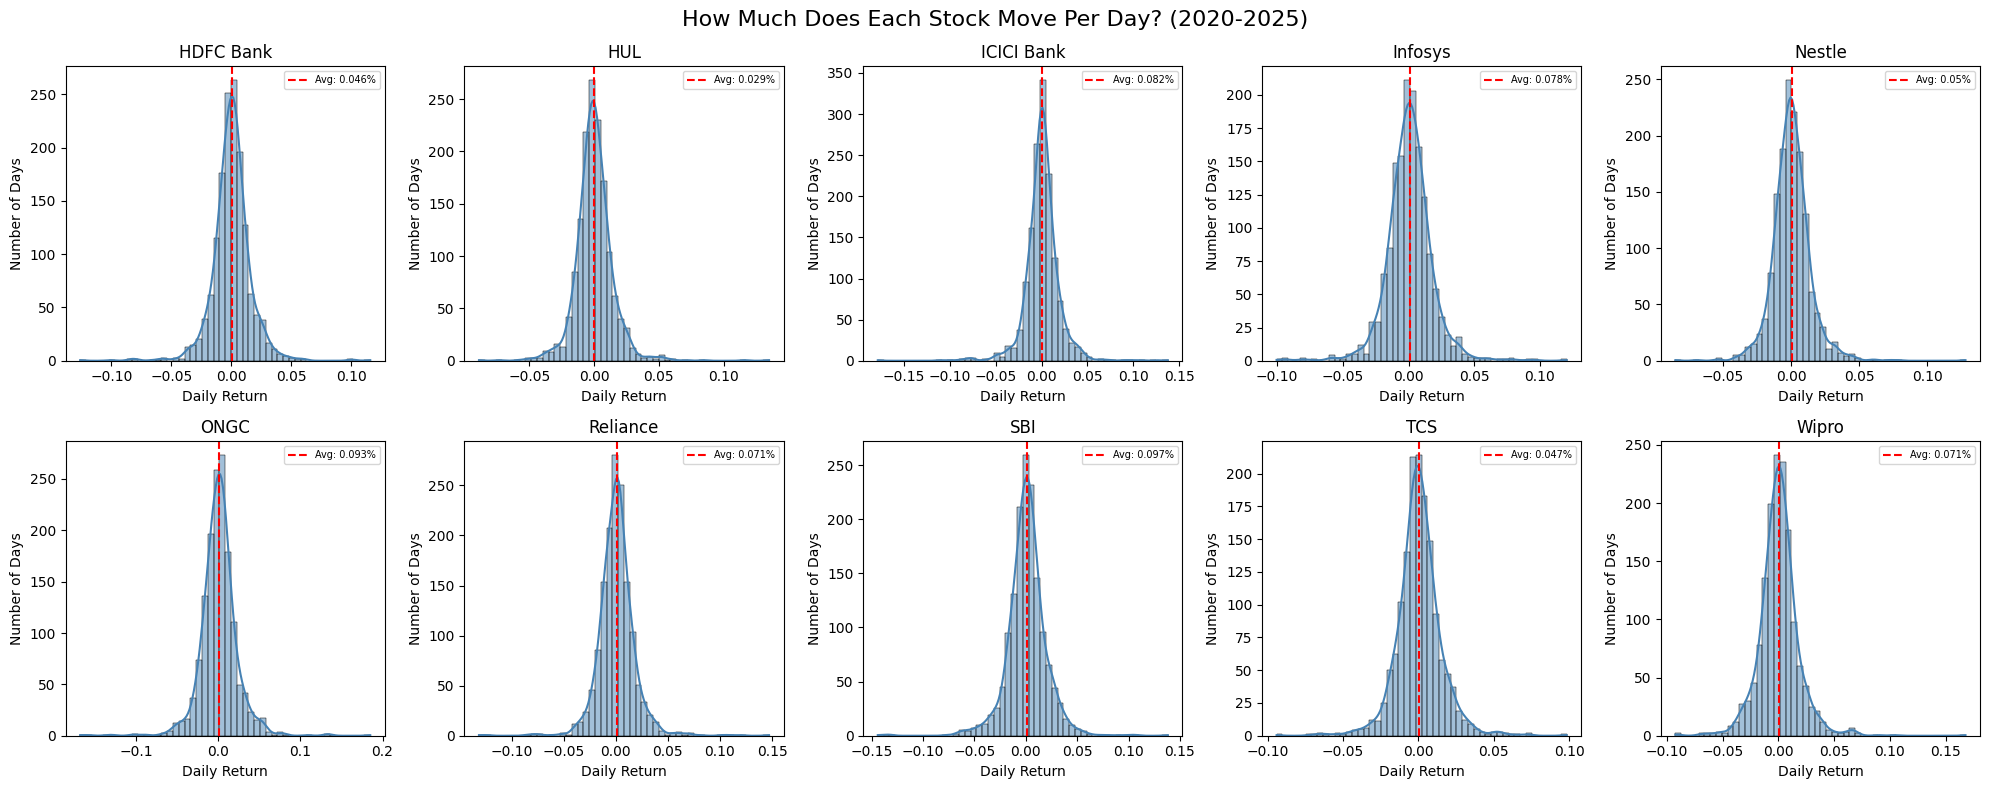

Summary of Daily Returns:

            Avg Daily Return %  Std Dev %  Worst Day %  Best Day %
ONGC                     0.093      2.298       -16.83       18.51
SBI                      0.097      1.956       -14.40       13.83
ICICI Bank               0.082      1.872       -17.85       13.76
Wipro                    0.071      1.806        -9.22       16.78
Reliance                 0.071      1.781       -13.15       14.72
Infosys                  0.078      1.727       -10.04       12.03
HDFC Bank                0.046      1.618       -12.61       11.60
TCS                      0.047      1.497        -9.41        9.85
HUL                      0.029      1.460        -8.87       13.50
Nestle                   0.050      1.384        -8.49       12.80


In [7]:
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
fig.suptitle('How Much Does Each Stock Move Per Day? (2020-2025)', fontsize=16)

for stock, ax in zip(returns.columns, axes.flatten()):

    sns.histplot(returns[stock], kde=True, bins=50, ax=ax, color='steelblue')

    mean_val = round(returns[stock].mean() * 100, 3)
    ax.axvline(returns[stock].mean(), color='red',
               linestyle='--', label='Avg: ' + str(mean_val) + '%')

    ax.set_title(stock)
    ax.set_xlabel('Daily Return')
    ax.set_ylabel('Number of Days')
    ax.legend(fontsize=7)

plt.tight_layout()
plt.show()

print('Summary of Daily Returns:')
print()
summary = pd.DataFrame({
    'Avg Daily Return %' : (returns.mean() * 100).round(3),
    'Std Dev %'          : (returns.std() * 100).round(3),
    'Worst Day %'        : (returns.min() * 100).round(2),
    'Best Day %'         : (returns.max() * 100).round(2)
})
print(summary.sort_values('Std Dev %', ascending=False))

### What we can see from this plot

**Safest stocks (tall and narrow):**
- Nestle and TCS have the tallest narrowest charts —
  they barely move most days, very predictable
- HDFC Bank and HUL are also quite narrow and stable

**Riskiest stocks (short and wide):**
- ONGC has the widest chart — it has the biggest daily swings
  you can clearly see it spreads much further left and right
- ICICI Bank and SBI are the widest among banking stocks

**All stocks share one thing:**
- Every stock is centred around 0 on the x-axis
  meaning most days the stock barely moves up or down
- Big moves (far left or far right) are rare but do happen
  — those were days like the COVID crash in March 2020

**Simple conclusion:**
- FMCG stocks (Nestle, HUL) = safest, narrowest charts
- Energy stocks (ONGC, Reliance) = riskiest, widest charts
- Low Risk = Invest in FMCG
- High Risk = High Reward = Invest in Energy

---
### Plot 3 — Which Stocks Are Riskiest?
**What are we looking at?**
Standard deviation (Std Dev) measures how much a stock's price jumps around.

Think of it like this:
- **High std dev** = the stock is unpredictable
- **Low std dev** = the stock is stable and predictable

We use std dev of daily returns as our measure of risk.

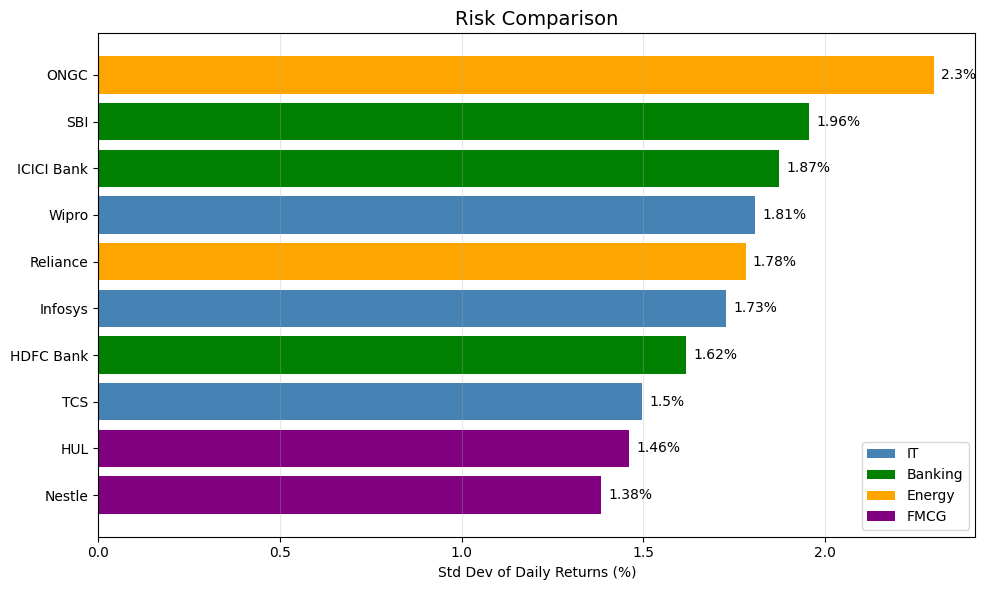

Risk Ranking (Safest to Riskiest):
Nestle -> 1.38%
HUL -> 1.46%
TCS -> 1.5%
HDFC Bank -> 1.62%
Infosys -> 1.73%
Reliance -> 1.78%
Wipro -> 1.81%
ICICI Bank -> 1.87%
SBI -> 1.96%
ONGC -> 2.3%


In [8]:
volatility = (returns.std() * 100).sort_values(ascending=True)

colors = []
for stock in volatility.index:
    colors.append(sector_colors[stock])

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(volatility.index, volatility.values, color=colors)

for bar, val in zip(bars, volatility.values):
    ax.text(bar.get_width() + 0.02,
            bar.get_y() + bar.get_height() / 2,
            str(round(val, 2)) + '%',
            va='center', fontsize=10)

ax.set_title('Risk Comparison', fontsize=14)
ax.set_xlabel('Std Dev of Daily Returns (%)')
ax.grid(True, alpha=0.3, axis='x')

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='steelblue', label='IT'),
    Patch(facecolor='green',     label='Banking'),
    Patch(facecolor='orange',    label='Energy'),
    Patch(facecolor='purple',    label='FMCG')
]
ax.legend(handles=legend_elements, loc='lower right')

plt.tight_layout()
plt.show()

print('Risk Ranking (Safest to Riskiest):')
for stock, val in zip(volatility.index, volatility.values):
    print(stock, '->', str(round(val, 2)) + '%')

**What we can see from this plot:**
- ONGC (2.30%) is the riskiest — its price jumps around the most each day
- Nestle (1.38%) is the safest — very stable, barely moves day to day
- FMCG stocks (purple) are all at the safe end — people buy daily commodities every day regardless of economy
- Energy stocks (orange) are at the risky end — oil prices change constantly with world events
- Within Banking: SBI is riskier than HDFC Bank because it is a government bank with more exposure to bad loans

---
### Plot 4 — Do Stocks Move Together?
**What are we looking at?**
Correlation tells us if two stocks tend to go up and down on the same days.

- **Score near 1.0** = they almost always move together
- **Score near 0.0** = they move independently — one goes up, other does nothing
- **Score near -1.0** = they move opposite — one goes up, other goes down

**Why does this matter?**
If you invest in two stocks that always move together, you are not really diversifying.
True diversification = picking stocks with low correlation to each other.

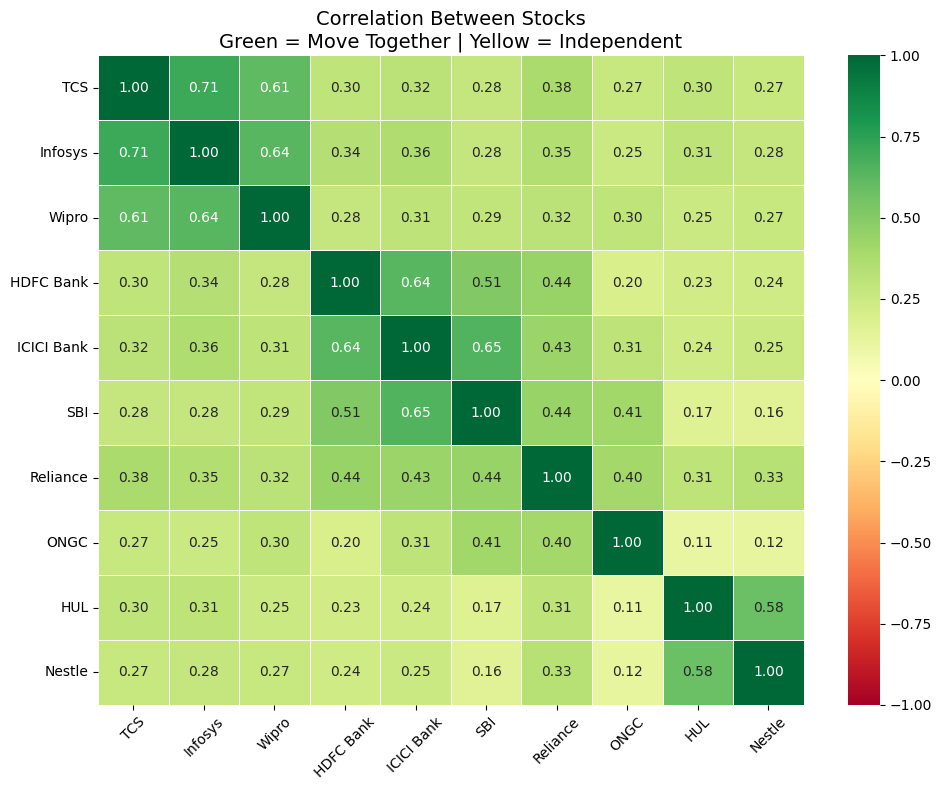

Top 5 Most Correlated Pairs (move together):
TCS         Infosys       0.71
Infosys     TCS           0.71
ICICI Bank  SBI           0.65
SBI         ICICI Bank    0.65
ICICI Bank  HDFC Bank     0.64
dtype: float64

Top 5 Least Correlated Pairs (most independent):
HUL     ONGC      0.11
ONGC    HUL       0.11
Nestle  ONGC      0.12
ONGC    Nestle    0.12
Nestle  SBI       0.16
dtype: float64


In [9]:
corr_matrix = returns.corr().round(2)

sector_order = [
    'TCS', 'Infosys', 'Wipro',          # IT
    'HDFC Bank', 'ICICI Bank', 'SBI',   # Banking
    'Reliance', 'ONGC',                 # Energy
    'HUL', 'Nestle'                     # FMCG
]
corr_ordered = returns[sector_order].corr().round(2)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_ordered,
            annot=True,
            fmt='.2f',
            cmap='RdYlGn',
            center=0,
            vmin=-1, vmax=1,
            linewidths=0.5,
            ax=ax)

ax.set_title('Correlation Between Stocks\nGreen = Move Together | Yellow = Independent',
             fontsize=14)
ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

corr_pairs = corr_matrix.unstack() 
corr_pairs = corr_pairs[corr_pairs < 1.0]

print('Top 5 Most Correlated Pairs (move together):')
print(corr_pairs.sort_values(ascending=False).head(5).round(2))

print('\nTop 5 Least Correlated Pairs (most independent):')
print(corr_pairs.sort_values(ascending=True).head(5).round(2))

### What we can see from this plot

**Stocks that move together (dark green):**
- TCS and Infosys (0.71) — both are large IT companies that depend on the same US clients, so they react to the same news
- ICICI Bank and SBI (0.65) — both banks are affected by the same RBI interest rate decisions
- ICICI Bank and HDFC Bank (0.64) — all 3 banking stocks move very similarly

**Stocks that are independent (yellow):**
- HUL and ONGC (0.11) — almost no connection at all. HUL sells daily commodities, ONGC sells oil — completely different businesses
- Nestle and ONGC (0.12) — same reason, FMCG and Energy have nothing in common

**What this means in simple terms:**
- Buying TCS + Infosys together is pointless for diversification — they move almost identically
- Buying HUL + ONGC together is smart — when one falls the other is not affected

**Best 3 stock combination from this data:**
TCS + SBI + HUL — one from each of IT, Banking and FMCG with low overlap between them

---
# 📋 Final Summary
## Indian Stock Market Analysis (2020–2025)

---

### What we studied
- 10 famous Indian stocks across 4 sectors
- 5 years of data from January 2020 to December 2025
- Data downloaded directly from Yahoo Finance

---

### Finding 1 — Price Trends
- Every single stock crashed in March 2020 when India announced the COVID lockdown
- Markets recovered strongly after the Pfizer vaccine news in November 2020
- Election Results in June 2024 caused a sudden dip visible across all sectors
- Trump Tariffs in April 2025 caused another market-wide drop

---

### Finding 2 — Daily Movement
- Every stock moves up or down a little every single day
- ONGC moves the most on average (2.30% per day) — very unpredictable
- Nestle moves the least (1.38% per day) — very stable
- The biggest single day crashes happened during COVID in March 2020

---

### Finding 3 — Risk
| Sector | Risk Level | Why |
|---|---|---|
| FMCG | Lowest | People buy daily products regardless of economy |
| IT | Medium | Depends on global tech demand |
| Banking | Medium-High | Sensitive to interest rate changes |
| Energy | Highest | Oil prices change with every world event |

---

### Finding 4 — Correlation
- TCS and Infosys (0.71) always move together — investing in both gives no extra safety
- HUL and ONGC (0.11) are almost completely independent — best combination for safety
- Stocks within the same sector move very similarly to each other

---

### Key Takeaway
> Sector choice matters more than individual stock picking.
> All stocks within a sector tend to move together.
> The safest portfolio combines stocks from different sectors —
> **TCS + SBI + HUL** is the best 3 stock combination from this dataset.